Start date: 2021-04-01
End date: 2021-04-30

Removing all cloudnet files of LWC and Reff from its directory...

All file removed

Computating cloud microphysics for liquid clouds

Files = 1/30


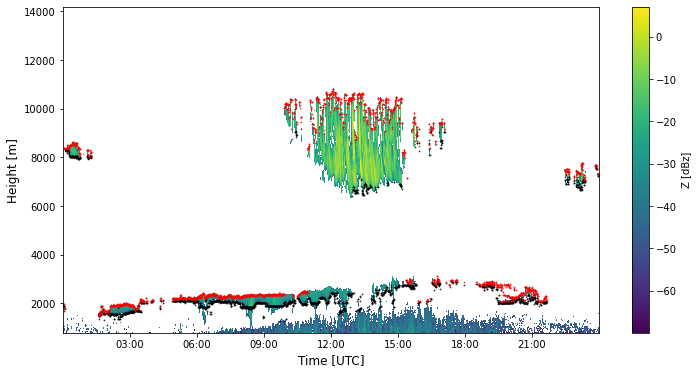

/home/matheustolen/.conda/envs/matheustolenenv/lib/python3.9/site-packages/numpy/ma/core.py:1013: RuntimeWarning: overflow encountered in multiply
  result = self.f(da, db, *args, **kwargs)


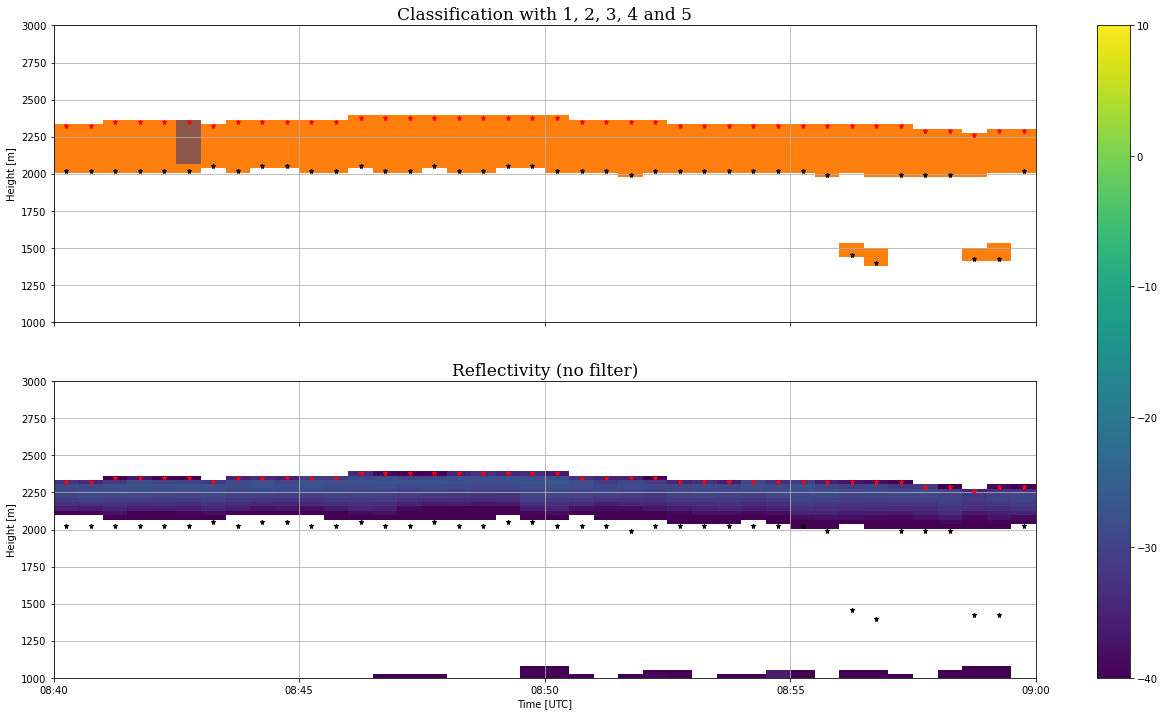

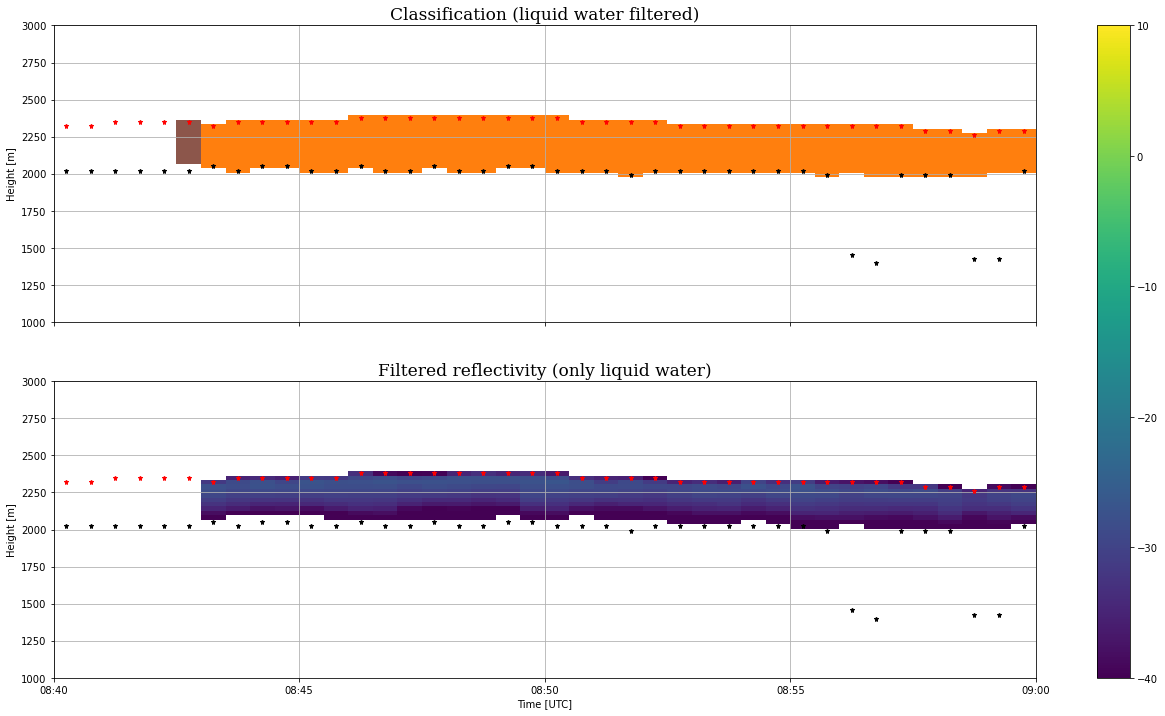

/tmp/ipykernel_823662/739485170.py:937: RuntimeWarning: divide by zero encountered in double_scalars
  return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z) ) )**2


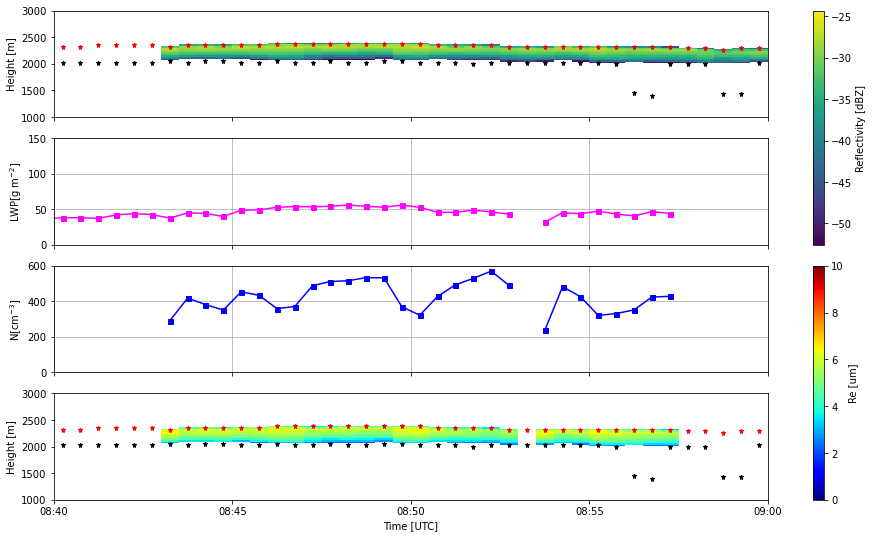

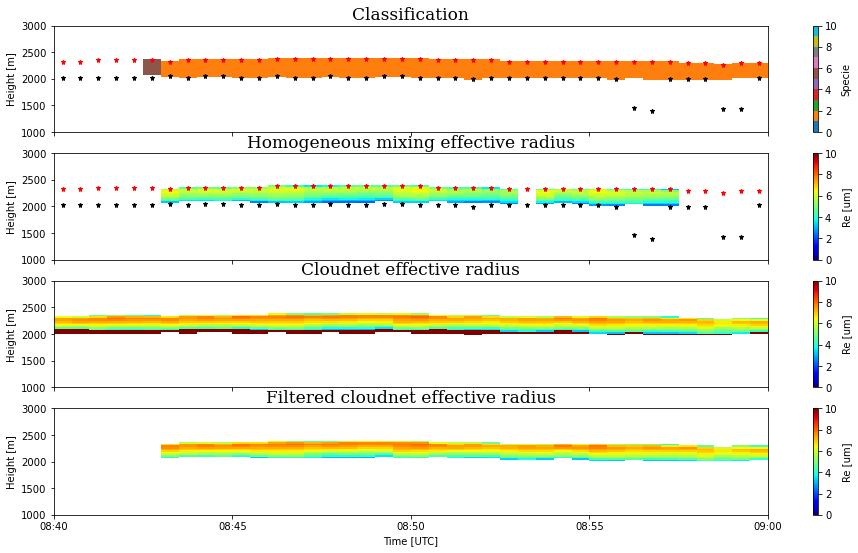

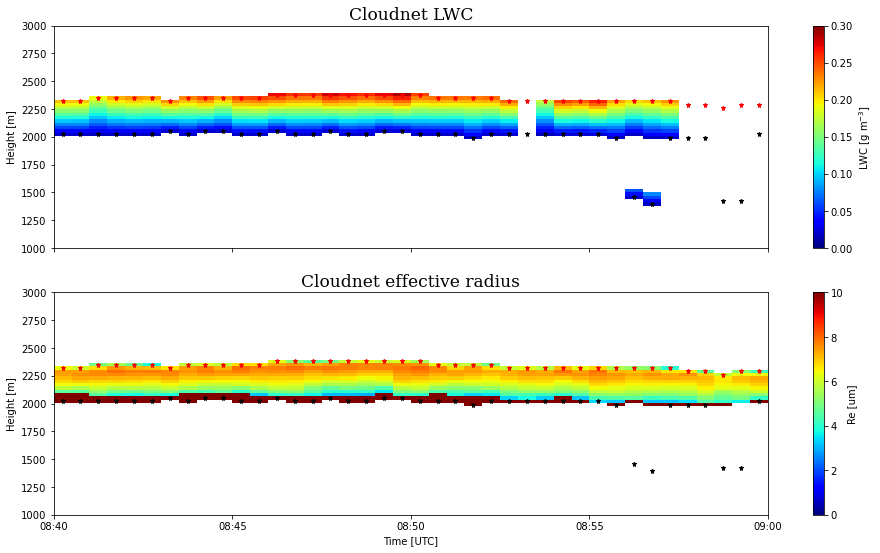

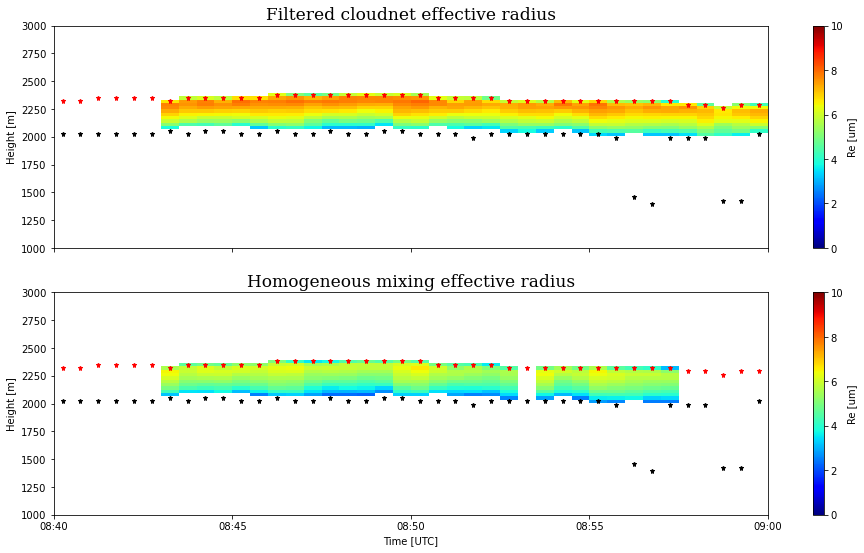

In [1]:
#-------------------------------------------------------------------------------------------------------
# import classes
#-------------------------------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import ion
import netCDF4 as nc
from datetime import timedelta
import matplotlib.dates as mdates
from scipy import interpolate, integrate
from pandas.tseries.frequencies import to_offset
import datetime
import matplotlib as mpl
import pandas as pd
import os
#-------------------------------------------------------------------------------------------------------
from cloudnetpy.products import generate_lwc
from cloudnetpy.products import generate_der
from cloudnetpy.products.der import Parameters
#-------------------------------------------------------------------------------------------------------
#from cloud_classes import Intersection_products, HMmodel, Cloud_filters
#-------------------------------------------------------------------------------------------------------
# paths
#-------------------------------------------------------------------------------------------------------
PATH_CLASS        = '../../data/classification/'
PATH_CATE         = '../../data/categorize/'
PATH_FIG          = '../figures/'
PATH_CLOUDNET_LWC = '../../retrievals_cloudnet/liquid_cloud/lwc/'
PATH_CLOUDNET_DER = '../../retrievals_cloudnet/liquid_cloud/der/'
#-------------------------------------------------------------------------------------------------------
# constants
#-------------------------------------------------------------------------------------------------------
CLOUD_LIQUID                    = 1   # Cloud liquid droplets only
DRIZZLE_OR_RAIN                 = 2   # Drizzle or rain
DRIZZLE_OR_RAIN_LIQUID_DROPLETS = 3   # Drizzle or rain coexisting with cloud liquid droplets
ICE_PARTICLES                   = 4   # Ice particles
ICE_WITH_SUP_WATER              = 5   # Ice coexisting with supercooled liquid droplets.
THRESHOLD_BELLOW                = 500 # [ m ]
THRESHOLD_ABOVE                 = 500 # [ m ]
FONT                            = {'family': 'serif',
                                   'color':  'black',
                                   'weight': 'normal',
                                   'size': 17,
                                   }
ion()
def main():
    cloudnet_example = Intersection_products(PATH_CLASS, PATH_CATE)
    start_date       = min(cloudnet_example.dates) # first date of database
    end_date         = max(cloudnet_example.dates) # last date of database
    date_complete    = pd.date_range( start=start_date, end=end_date ) # datetime with all days between
                                                                       # start and end dates
    print("Start date:", start_date.date())
    print("End date:", end_date.date())
    #----------------------------------------------------------------------------------------------------
    # verification
    #----------------------------------------------------------------------------------------------------
    # check date gaps in database:
    i = 0
    for date in date_complete:
        if date == cloudnet_example.dates[i]: # day check
            i+=1
        else:
            print("\nThere is no data for:", date.date()) # missing data
            # ADD NaN        
    # date_ex = cloudnet_example.dates[28] # 29/04/2021
    # i = 20 case with diferent resolution 
    # NOTE: If working in a server without adm permission the following two lines should 
    # be discomented
    print("\nRemoving all cloudnet files of LWC and Reff from its directory...")
    os.system("rm "+PATH_CLOUDNET_LWC+"*lwc.nc") # remove all lwc files from lwc path 
    os.system("rm "+PATH_CLOUDNET_DER+"*der.nc") # remove all der files from der path
    print("\nAll file removed")
    date_test = [cloudnet_example.dates[28]]
    #----------------------------------------------------------------------------------------------------
    # initialize variables
    #----------------------------------------------------------------------------------------------------
    
    #----------------------------------------------------------------------------------------------------
    # uncomment the following line for a complete database analysis
    # and of course, comment the next loop :)
    print("\nComputating cloud microphysics for liquid clouds")
    #for i, date in enumerate(cloudnet_example.dates):
    n = len(cloudnet_example.dates)
    for i, date in enumerate(date_test):
    #----------------------------------------------------------------------------------------------------
        print("\nFiles = %d/%d"%(i+1, n))
        #------------------------------------------------------------------------------------------------
        # reading categorize and classification files 
        #------------------------------------------------------------------------------------------------
        categorize     = nc.Dataset(PATH_CATE+cloudnet_example.var_files[date])
        classification = nc.Dataset(PATH_CLASS+cloudnet_example.classification_files[date])
        #------------------------------------------------------------------------------------------------
        # cloudnet algorithm to generate netcdf files with liquid water content (lwc) and droplet 
        # effective radius (der)
        #------------------------------------------------------------------------------------------------
        generate_lwc(PATH_CATE+cloudnet_example.var_files[date], 
                     PATH_CLOUDNET_LWC+cloudnet_example.var_files[date][:17]+'lwc.nc')
        
        params = Parameters(2.0, 100.0e6, 200.0e6, 0.25, 0.1, 5.0e-3)
        generate_der(PATH_CATE+cloudnet_example.var_files[date],
                     PATH_CLOUDNET_DER+cloudnet_example.var_files[date][:17]+'der.nc', 
                     parameters=params)
        #------------------------------------------------------------------------------------------------
        # reading lwc and der files generated by the last code block
        #------------------------------------------------------------------------------------------------
        cloudnet_lwc = nc.Dataset(PATH_CLOUDNET_LWC+cloudnet_example.var_files[date][:17]+'lwc.nc')
        cloudnet_der = nc.Dataset(PATH_CLOUDNET_DER+cloudnet_example.var_files[date][:17]+'der.nc')
        
        # check if categorize and classification files have the same time resolution 
        if classification.dimensions['time'].size == categorize.dimensions['time'].size\
        and sum(categorize['time'][:] == classification['time'][:]) == categorize.dimensions['time'].size:
            
            time_auxiliary  = []
            for h in categorize['time']:
                time_auxiliary.append( cloudnet_example.var_files[date][:8]\
                                      + ' ' + str(timedelta(hours=float(h))) )
            time = pd.to_datetime(time_auxiliary, format = "%Y%m%d %H:%M:%S" )
        else:
            print("Red flag: classification and categorize files with diferent time resolution - ",
                  time.date())
        
        #------------------------------------------------------------------------------------------------
        # verification: plot time interval
        #------------------------------------------------------------------------------------------------
        # a1 = np.diff(classification['time'][:30])*3600
        # a2 = np.diff(categorize['time'][:30])*3600
        # plt.figure()
        # plt.plot(a1, '-o',label='classification')
        # plt.plot(a2, '-o', label='categorize')
        # plt.ylabel(r'$\Delta T\ [s]$')
        # plt.legend()
        # plt.ylim([25, 40])
        # plt.show()
        #------------------------------------------------------------------------------------------------
        # verification: plot one profile of reflectivity (comment this block if nedeed)
        #------------------------------------------------------------------------------------------------
#         t = 500
#         fig = plt.figure(figsize=[5, 8])
#         ax1 = plt.subplot()

#         colormesh = plt.plot(categorize['Z'][t,:], categorize['height'][:]/1000, marker='o')

#         xlabx = ax1.xaxis.get_label()
#         xlaby = ax1.yaxis.get_label()
    
#         xlabx.set_size(12)
#         xlaby.set_size(12)
#         ax1.set_ylabel(r'Height [km]')
#         ax1.set_xlabel(r'Reflectivity [dBZ]')
#         plt.show()
        #------------------------------------------------------------------------------------------------
        # verification: plot reflectivity time serie, cloud base and cloud top 
        #------------------------------------------------------------------------------------------------
        fig = plt.figure(figsize=[12, 6])
        axs = plt.subplot()

        colormesh = plt.pcolormesh(time, categorize['height'][:],
                                   np.transpose(categorize['Z'][:]),
                                   cmap='viridis',
                                   shading='nearest')
        p1        = plt.scatter(time, classification['cloud_base_height_amsl'][:],
                                s=1, c='black', alpha=.7, marker='*')
        p2        = plt.scatter(time, classification['cloud_top_height_amsl'][:],
                                s=1, c='red', alpha=.7, marker='*')

        xlabx = axs.xaxis.get_label()
        xlaby = axs.yaxis.get_label()
        cbar = plt.colorbar(colormesh)
        cbar.set_label(r'Z [dBz]')
        xlabx.set_size(12)
        xlaby.set_size(12)
        axs.set_ylabel(r'Height [m]')
        axs.set_xlabel(r'Time [UTC]')
        axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        #plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
        plt.show()
        #------------------------------------------------------------------------------------------------
        # verification: plot classification time serie
        #------------------------------------------------------------------------------------------------
#         fig = plt.figure(figsize=[12, 6])
#         axs = plt.subplot()

#         colormesh = plt.pcolormesh(time, classification['height'][:],
#                                    np.transpose(classification['target_classification'][:]),
#                                    cmap='tab10',
#                                    shading='nearest',
#                                   vmin=0,
#                                   vmax=10)

#         fig.colorbar(colormesh, ax=axs, ticks=list(range(11)))
#         #cbar.set_ticks([mn,md,mx])
#         axs.set_ylabel(r'Height [m]')
#         axs.set_xlabel(r'Time [UTC]')
#         axs.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#         #plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
#         plt.show()
        #------------------------------------------------------------------------------------------------
        # creating variables as dataframe with time series as the index
        # and altitude as columns 
        #------------------------------------------------------------------------------------------------
        df_cloud_base     = pd.DataFrame(data   =classification['cloud_base_height_amsl'][:], 
                                         index  =time )
        df_cloud_top      = pd.DataFrame(data   =classification['cloud_top_height_amsl'][:],
                                         index  =time )
        df_reflectivity   = pd.DataFrame(data   =categorize['Z'][:],
                                         index  =time,
                                         columns=categorize['height'][:])
        df_lwp            = pd.DataFrame(data   =categorize['lwp'][:], 
                                         index  =time )

        df_classification = pd.DataFrame(data=np.where(   (classification['target_classification'][:] != CLOUD_LIQUID)\
                                                        & (classification['target_classification'][:] != DRIZZLE_OR_RAIN)\
                                                        & (classification['target_classification'][:] != DRIZZLE_OR_RAIN_LIQUID_DROPLETS)\
                                                        & (classification['target_classification'][:] != ICE_PARTICLES)\
                                                        & (classification['target_classification'][:] != ICE_WITH_SUP_WATER),
                                                        np.NaN, 
                                                        classification['target_classification'][:]),
                                         index  =time,
                                         columns=classification['height'])

        df_cloudnet_lwc   = pd.DataFrame(data   =1.0e3*cloudnet_lwc['lwc'][:],
                                         index  =time,
                                         columns=cloudnet_lwc['height'][:]) # g m^-3
        df_cloudnet_der   = pd.DataFrame(data   =1.0e6*cloudnet_der['der'][:],
                                         index  =time,
                                         columns=cloudnet_der['height'][:]) # um
        
        #------------------------------------------------------------------------------------------------
        # test: time and thickness filter 
        #------------------------------------------------------------------------------------------------
        classification_filter = Cloud_filters(df_classification.copy(), CLOUD_LIQUID)
        classification_filter.filtering_dz(100) # [ m ]
        classification_filter.filtering_dt(5)  # [ min ]
        #------------------------------------------------------------------------------------------------
        # test: plot the result of time and thickness filter 
        #------------------------------------------------------------------------------------------------
#         hour_s = 1
#         hour_e = 3
#         min_s  = 34
#         min_e  = 45
#         z_min  = df_classification.columns.min() + 300   # m
#         z_max  = 2300 # m

#         fig, axs = plt.subplots(2, sharex=True, figsize=(18, 10))

#         f0       = axs[0].pcolormesh(df_classification.index,
#                                      df_classification.columns, 
#                                      np.transpose(df_classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[0].set_ylabel(r'Height [m]')
#         axs[0].set_ylim([z_min,z_max])
#         axs[0].grid()

#         f3       = axs[1].pcolormesh(classification_filter.classification.index, 
#                                      classification_filter.classification.columns, 
#                                      np.transpose(classification_filter.classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[1].set_ylabel(r'Height [m]')
#         axs[1].set_xlabel(r'Time [UTC]')
#         fig.colorbar(f3, ax=axs[0:3])
#         #axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
#         axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#         axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
#                          classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
#         axs[1].set_ylim([z_min,z_max])
#         axs[1].grid()
#         plt.show()
        
        #------------------------------------------------------------------------------------------------
        # test: DRIZZLE_OR_RAIN filter 
        #------------------------------------------------------------------------------------------------
        classification_filter = Cloud_filters(df_classification.copy(), CLOUD_LIQUID)
        dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(DRIZZLE_OR_RAIN)
        classification_filter.filtering_specie(DRIZZLE_OR_RAIN, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        #------------------------------------------------------------------------------------------------
        # test: plot the result of DRIZZLE_OR_RAIN 
        #------------------------------------------------------------------------------------------------
#         hour_s   = 8
#         hour_e   = 9
#         z_min    = df_classification.columns.min() + 300   # m
#         z_max    = 4000 # m
#         fig, axs = plt.subplots(2, sharex=True, figsize=(18, 10))

#         f0       = axs[0].pcolormesh(df_classification.index, 
#                                      df_classification.columns, 
#                                      np.transpose(df_classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[0].set_ylabel(r'Height [m]')
#         axs[0].set_ylim([z_min,z_max])
#         axs[0].grid()

#         f1       = axs[1].pcolormesh(classification_filter.classification.index, 
#                                      classification_filter.classification.columns, 
#                                      np.transpose(classification_filter.classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[1].set_ylabel(r'Height [m]')
#         axs[1].set_xlabel(r'Time [UTC]')
#         fig.colorbar(f1, ax=axs[0:3])
#         #axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
#         axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#         axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
#                          classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
#         axs[1].set_ylim([z_min,z_max])
#         axs[1].grid()
#         plt.show()
        #------------------------------------------------------------------------------------------------
#         fig, axs = plt.subplots(figsize=(10, 6))

#         p1       = axs.hist(dz_bellow, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
#         axs.grid()
#         plt.show()

#         fig, axs = plt.subplots(figsize=(10, 6))

#         p2       = axs.hist(dz_above, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
#         axs.grid()
#         plt.show() 
        #------------------------------------------------------------------------------------------------
        # test: DRIZZLE_OR_RAIN_LIQUID_DROPLETS filter 
        #------------------------------------------------------------------------------------------------
        classification_filter = Cloud_filters(df_classification.copy(), CLOUD_LIQUID)
        dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(DRIZZLE_OR_RAIN_LIQUID_DROPLETS)
        classification_filter.filtering_specie(DRIZZLE_OR_RAIN_LIQUID_DROPLETS, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        #------------------------------------------------------------------------------------------------
        # test: plot the result of DRIZZLE_OR_RAIN_LIQUID_DROPLETS 
        #------------------------------------------------------------------------------------------------
#         hour_s   = 12
#         hour_e   = 13
#         z_min    = df_classification.columns.min() + 300   # m
#         z_max    = 4000 # m
#         fig, axs = plt.subplots(2, sharex=True, figsize=(18, 10))

#         f0       = axs[0].pcolormesh(df_classification.index, 
#                                      df_classification.columns, 
#                                      np.transpose(df_classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)


#         axs[0].set_ylabel(r'Height [m]')
#         axs[0].set_ylim([z_min,z_max])
#         axs[0].grid()

#         f1       = axs[1].pcolormesh(classification_filter.classification.index, 
#                                      classification_filter.classification.columns, 
#                                      np.transpose(classification_filter.classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[1].set_ylabel(r'Height [m]')
#         axs[1].set_xlabel(r'Time [UTC]')
#         fig.colorbar(f1, ax=axs[0:3])
#         #axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
#         axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#         axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
#                          classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
#         axs[1].set_ylim([z_min,z_max])
#         axs[1].grid()
#         plt.show()
        #------------------------------------------------------------------------------------------------
#         fig, axs = plt.subplots(figsize=(10, 6))

#         p1       = axs.hist(dz_bellow, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
#         axs.grid()
#         plt.show()

#         fig, axs = plt.subplots(figsize=(10, 6))

#         p2       = axs.hist(dz_above, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
#         axs.grid()
#         plt.show()
        #------------------------------------------------------------------------------------------------
        # test: ICE_PARTICLES filter 
        #------------------------------------------------------------------------------------------------
        classification_filter = Cloud_filters(df_classification.copy(), CLOUD_LIQUID)
        dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(ICE_PARTICLES)
        classification_filter.filtering_specie(ICE_PARTICLES, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        #------------------------------------------------------------------------------------------------
        # test: plot the result of ICE_PARTICLES 
        #------------------------------------------------------------------------------------------------
#         hour_s   = 11
#         hour_e   = 12
#         z_min    = df_classification.columns.min() + 300   # m
#         z_max    = 3000 # m
#         fig, axs = plt.subplots(2, sharex=True, figsize=(18, 10))

#         f0       = axs[0].pcolormesh(df_classification.index, 
#                                      df_classification.columns, 
#                                      np.transpose(df_classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[0].set_ylabel(r'Height [m]')
#         axs[0].set_ylim([z_min,z_max])
#         axs[0].grid()

#         f1       = axs[1].pcolormesh(classification_filter.classification.index, 
#                                      classification_filter.classification.columns, 
#                                      np.transpose(classification_filter.classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[1].set_ylabel(r'Height [m]')
#         axs[1].set_xlabel(r'Time [UTC]')
#         fig.colorbar(f1, ax=axs[0:3])
#         #axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
#         axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#         axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
#                  classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
#         axs[1].set_ylim([z_min,z_max])
#         axs[1].grid()
#         plt.show()
        #------------------------------------------------------------------------------------------------
#         fig, axs = plt.subplots(figsize=(10, 6))

#         p1       = axs.hist(dz_bellow, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
#         axs.grid()
#         plt.show()

#         fig, axs = plt.subplots(figsize=(10, 6))

#         p2       = axs.hist(dz_above, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
#         axs.grid()
#         plt.show()
        #------------------------------------------------------------------------------------------------
        # test: ICE_WITH_SUP_WATER filter
        #------------------------------------------------------------------------------------------------
        classification_filter = Cloud_filters(df_classification.copy(), CLOUD_LIQUID)
        dz_bellow, dz_above   = classification_filter.quantile_nearest_pixel(ICE_WITH_SUP_WATER)
        classification_filter.filtering_specie(ICE_WITH_SUP_WATER, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        #------------------------------------------------------------------------------------------------
        # test: plot the result of ICE_WITH_SUP_WATER filter
        #------------------------------------------------------------------------------------------------
#         hour_s   = 19
#         hour_e   = 20
#         z_min    = df_classification.columns.min() + 300   # m
#         z_max    = 4000 # m
#         fig, axs = plt.subplots(2, sharex=True, figsize=(18, 10))

#         f0       = axs[0].pcolormesh(df_classification.index, 
#                                      df_classification.columns, 
#                                      np.transpose(df_classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[0].set_ylabel(r'Height [m]')
#         axs[0].set_ylim([z_min,z_max])
#         axs[0].grid()

#         f1       = axs[1].pcolormesh(classification_filter.classification.index, 
#                                      classification_filter.classification.columns, 
#                                      np.transpose(classification_filter.classification),
#                                      cmap='tab10',
#                                      vmin=0,
#                                      vmax=10)

#         axs[1].set_ylabel(r'Height [m]')
#         axs[1].set_xlabel(r'Time [UTC]')
#         fig.colorbar(f1, ax=axs[0:3])
#         #axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
#         axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#         axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s), 
#                          classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e)])
#         axs[1].set_ylim([z_min,z_max])
#         axs[1].grid()
#         plt.show()
        #------------------------------------------------------------------------------------------------
#         fig, axs = plt.subplots(figsize=(10, 6))

#         p0       = axs.hist(dz_bellow, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Bellow Cloud [m]')
#         axs.grid()
#         plt.show()

#         fig, axs = plt.subplots(figsize=(10, 6))

#         p1       = axs.hist(dz_above, bins=20, edgecolor='black')
#         #plot3 = axs.boxplot(dz_bellow)
#         axs.set_ylabel(r'Counts')
#         axs.set_xlabel(r'$\Delta z$ Above Cloud [m]')
#         axs.grid()
#         plt.show()
        
        #------------------------------------------------------------------------------------------------
        # result: Classification filter 
        #------------------------------------------------------------------------------------------------
        classification_filter = Cloud_filters(df_classification.copy(), CLOUD_LIQUID)

        # The order is important. The delta time filter must be the last one
        classification_filter.filtering_specie(DRIZZLE_OR_RAIN, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        classification_filter.filtering_specie(DRIZZLE_OR_RAIN_LIQUID_DROPLETS, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        classification_filter.filtering_specie(ICE_PARTICLES, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        classification_filter.filtering_specie(ICE_WITH_SUP_WATER, THRESHOLD_BELLOW, THRESHOLD_ABOVE)
        classification_filter.filtering_dz(200) # meters
        classification_filter.filtering_dt(10)  # minutes

        liquid_classification = classification_filter.classification.where(classification_filter.classification\
                                               == CLOUD_LIQUID, np.nan)
        for time in liquid_classification.index:
            row = np.where(liquid_classification.loc[time]==CLOUD_LIQUID)[0]
            if row.size:
                layers = len(groupSequence(row))
                if layers > 1:
                    print("More than 1 cloud layer, what to do with the LWC?")

        ze_filtered  = classification_filter.filtered_ze(df_reflectivity.copy()) 
        der_filtered = classification_filter.filtered_ze(df_cloudnet_der.copy())
        der_filtered.replace(np.nanmax(df_cloudnet_der), np.nan, inplace=True) # verificar
        df_cloudnet_lwc.replace(0, np.nan, inplace=True)
        #------------------------------------------------------------------------------------------------
        # result: plot classification and relfectivity without the filter
        #------------------------------------------------------------------------------------------------
        hour_s   = 8
        hour_e   = 9
        min_s    = 40
        min_e    = 0
        #z_min   = test.columns.min() + 300 # m
        z_min    = 1000
        z_max    = 3000 # m
        fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

        f0       = axs[0].pcolormesh(df_classification.index, 
                                     df_classification.columns, 
                                     np.transpose(df_classification),
                                     cmap='tab10',
                                     vmin=0,
                                     vmax=10)

        p1       = axs[0].plot(df_cloud_base, "*", color='black', markersize=5)
        p2       = axs[0].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[0].set_title("Classification with 1, 2, 3, 4 and 5" ,fontdict=FONT)
        axs[0].set_ylabel(r'Height [m]')
        axs[0].set_ylim([z_min,z_max])
        axs[0].grid()

        f1       = axs[1].pcolormesh(df_reflectivity.index, 
                                     df_reflectivity.columns, 
                                     np.transpose(df_reflectivity),
                                     cmap='viridis',
                                     vmin=-40,
                                     vmax=10)

        p3       = axs[1].plot(df_cloud_base, "*", color='black', markersize=5)
        p4       = axs[1].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[1].set_title("Reflectivity (no filter)" ,fontdict=FONT)
        axs[1].set_ylabel(r'Height [m]')
        axs[1].set_xlabel(r'Time [UTC]')
        fig.colorbar(f1, ax=axs[0:3])
        #axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
        axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axs[1].set_xlim([classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                         classification_filter.classification.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
        axs[1].set_ylim([z_min,z_max])
        axs[1].grid()
        plt.show()

        #------------------------------------------------------------------------------------------------
        # result: plot filtered classification 
        #------------------------------------------------------------------------------------------------
        fig, axs = plt.subplots(2, sharex=True, figsize=(22, 12))

        f0       = axs[0].pcolormesh(classification_filter.classification.index, 
                                     classification_filter.classification.columns, 
                                     np.transpose(classification_filter.classification),
                                     cmap='tab10',
                                     vmin=0,
                                     vmax=10)

        p5       = axs[0].plot(df_cloud_base, "*", color='black', markersize=5)
        p6       = axs[0].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[0].set_title("Classification (liquid water filtered)" ,fontdict=FONT)
        axs[0].set_ylabel(r'Height [m]')
        axs[0].set_ylim([z_min,z_max])
        axs[0].grid()

        f1       = axs[1].pcolormesh(ze_filtered.index, 
                                     ze_filtered.columns, 
                                     np.transpose(ze_filtered),
                                     cmap='viridis',
                                     vmin=-40,
                                     vmax=10)

        p7 = axs[1].plot(df_cloud_base, "*", color='black', markersize=5)
        p8 = axs[1].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[1].set_title("Filtered reflectivity (only liquid water)", fontdict=FONT)
        axs[1].set_ylabel(r'Height [m]')
        axs[1].set_xlabel(r'Time [UTC]')
        fig.colorbar(f1, ax=axs[0:3])
        #axs[1].xaxis.set_major_locator(mdates.MinuteLocator(interval = 1))
        axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axs[1].set_xlim([ze_filtered.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                         ze_filtered.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
        axs[1].set_ylim([z_min,z_max])
        axs[1].grid()
        plt.show()
        #------------------------------------------------------------------------------------------------
        # result: effective radius and number concentration
        #------------------------------------------------------------------------------------------------
        # initializing dataframes: effective radius and the number
        num_mh = pd.DataFrame(index=ze_filtered.index.array,
                              data=np.zeros(ze_filtered.shape[0])) # mh: homogeneos mixing 
        ref_mh = pd.DataFrame(data=np.zeros( (ze_filtered.shape[0], ze_filtered.shape[1])), 
                              index=ze_filtered.index.array, 
                              columns=categorize["height"][:])  # mh: homogeneos mixing

        for ind in ze_filtered.index:
            z_profile                 = ze_filtered.loc[ind]
            ze                        = 10**(z_profile[z_profile.notnull()]/10) # Remove NaNs 
                                                                                # and convert Z from 
                                                                                # dBz to mm^6 m^-3
            cloud_model               = HMmodel( df_lwp.loc[ind][0],
                                                ze.index.array,
                                                ze)
            num_mh.loc[ind]           = cloud_model.get_num()
            ref_mh.loc[ind, ze.index] = cloud_model.get_re()
    
        num_mh.replace([np.inf, -np.inf], np.nan, inplace=True)
        ref_mh.replace(0, np.nan, inplace=True)
        
        #------------------------------------------------------------------------------------------------
        # result: plot filtered reflectivity, liquid water path, number concentration and effective radius 
        #------------------------------------------------------------------------------------------------
        hour_s   = 8
        hour_e   = 9
        min_s    = 40
        min_e    = 0
        z_min    = 1000  # m
        z_max    = 3000 # m
        fig, axs = plt.subplots(4, sharex=True, figsize=(16, 9))

        f0       = axs[0].pcolormesh(ze_filtered.index, 
                                     ze_filtered.columns, 
                                     np.transpose(ze_filtered),
                                     cmap='viridis')
        p1       = axs[0].plot(df_cloud_base, "*", color='black', markersize=5)
        p2       = axs[0].plot(df_cloud_top, "*", color='red', markersize=5)

        axs[0].set_ylabel(r'Height [m]')
        fig.colorbar(f0, ax=axs[0:2],  label='Reflectivity [dBZ]')
        axs[0].set_ylim([z_min,z_max])

        f1       = axs[1].plot(df_lwp, "s-", color='magenta', markersize=5, markerfacecolor='magenta')
        axs[1].set_ylabel(r'LWP[g m$^{-2}$]')
        axs[1].set_ylim([0,150])
        axs[1].grid()

        f2       = axs[2].plot(num_mh, "-s", color='blue', markersize=5)
        axs[2].set_ylabel(r'N[cm$^{-3}$]')
        axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axs[2].set_ylim([0,600])
        axs[2].grid()

        f3       = axs[3].pcolormesh(ref_mh.index, 
                               ref_mh.columns, 
                               np.transpose(ref_mh),
                               cmap='jet',
                               vmin=0,
                               vmax=10)

        p3       = axs[3].plot(df_cloud_base, "*", color='black', markersize=5)
        p4       = axs[3].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[3].set_ylabel(r'Height [m]')
        axs[3].set_xlabel(r'Time [UTC]')
        fig.colorbar(f3, ax=axs[2:4], label='Re [um]')
        #axs.set_ylim([1000,2300])
        axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axs[3].set_xlim([ze_filtered.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                         ze_filtered.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
        axs[3].set_ylim([z_min,z_max])
        plt.show()
        #------------------------------------------------------------------------------------------------
        # result: plot cloudnet Re and LWC products
        #------------------------------------------------------------------------------------------------
        hour_s   = 8
        hour_e   = 9
        min_s    = 40
        min_e    = 0
        z_min    = 1000  # m
        z_max    = 3000 # m
        fig, axs = plt.subplots(4, sharex=True, figsize=(16, 9))

        f0       = axs[0].pcolormesh(classification_filter.classification.index, 
                                     classification_filter.classification.columns, 
                                     np.transpose(classification_filter.classification),
                                     cmap='tab10',
                                     vmin=0,
                                     vmax=10)

        p1       = axs[0].plot(df_cloud_base, "*", color='black', markersize=5)
        p2       = axs[0].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[0].set_ylabel(r'Height [m]')
        axs[0].set_ylim([z_min,z_max])
        axs[0].set_title("Classification", fontdict=FONT)
        fig.colorbar(f0, ax=axs[0:1], label='Specie')
        
        f1       = axs[1].pcolormesh(ref_mh.index, 
                                     ref_mh.columns, 
                                     np.transpose(ref_mh),
                                     cmap='jet', 
                                     vmin=0,
                                     vmax=10)
        p3       = axs[1].plot(df_cloud_base, "*", color='black', markersize=5)
        p4       = axs[1].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[1].set_ylabel(r'Height [m]')
        axs[1].set_ylim([z_min,z_max])
        axs[1].set_title("Homogeneous mixing effective radius", fontdict=FONT)
        fig.colorbar(f1, ax=axs[1:2], label='Re [um]')

        f2       = axs[2].pcolormesh(df_cloudnet_der.index, 
                                     df_cloudnet_der.columns, 
                                     np.transpose(df_cloudnet_der),
                                     cmap='jet', 
                                     vmin=0,
                                     vmax=10)

        axs[2].set_ylabel(r'Height [m]')
        axs[2].set_ylim([z_min,z_max])
        axs[2].set_title("Cloudnet effective radius", fontdict=FONT)
        fig.colorbar(f2, ax=axs[2:3], label='Re [um]')

        f3       = axs[3].pcolormesh(der_filtered.index, 
                                     der_filtered.columns, 
                                     np.transpose(der_filtered),
                                     cmap='jet', 
                                     vmin=0,
                                     vmax=10)

        axs[3].set_ylabel(r'Height [m]')
        axs[3].set_xlabel(r'Time [UTC]')
        axs[3].set_title("Filtered cloudnet effective radius", fontdict=FONT)
        fig.colorbar(f3, ax=axs[3:4], label='Re [um]')
        axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axs[3].set_xlim([ref_mh.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                         ref_mh.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
        axs[3].set_ylim([z_min,z_max])
        plt.show()
        
        #------------------------------------------------------------------------------------------------
        # result: plot cloudnet Re and LWC products
        #------------------------------------------------------------------------------------------------
        hour_s   = 8
        hour_e   = 9
        min_s    = 40
        min_e    = 0
        z_min    = 1000  # m
        z_max    = 3000 # m
        fig, axs = plt.subplots(2, sharex=True, figsize=(16, 9))

        f0       = axs[0].pcolormesh(df_cloudnet_lwc.index, 
                                     df_cloudnet_lwc.columns, 
                                     np.transpose(df_cloudnet_lwc),
                                     cmap='jet',
                                     vmin=0,
                                     vmax=.3)

        p1       = axs[0].plot(df_cloud_base, "*", color='black', markersize=5)
        p2       = axs[0].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[0].set_ylabel(r'Height [m]')
        axs[0].set_ylim([z_min,z_max])
        axs[0].set_title("Cloudnet LWC", fontdict=FONT)
        fig.colorbar(f0, ax=axs[0:1], label=r'LWC [g m$^{-3}$]')
        
        f1       = axs[1].pcolormesh(df_cloudnet_der.index, 
                                     df_cloudnet_der.columns, 
                                     np.transpose(df_cloudnet_der),
                                     cmap='jet', 
                                     vmin=0,
                                     vmax=10)
        p3       = axs[1].plot(df_cloud_base, "*", color='black', markersize=5)
        p4       = axs[1].plot(df_cloud_top, "*", color='red', markersize=5)

        axs[1].set_ylabel(r'Height [m]')
        axs[1].set_xlabel(r'Time [UTC]')
        axs[1].set_title("Cloudnet effective radius", fontdict=FONT)
        fig.colorbar(f2, ax=axs[1:2], label='Re [um]')
        axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axs[1].set_xlim([df_cloudnet_der.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                         df_cloudnet_der.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
        axs[1].set_ylim([z_min,z_max])
        plt.show()
        #------------------------------------------------------------------------------------------------
        # result: plot comparison between cloudnet Re and MH Re
        #------------------------------------------------------------------------------------------------
        hour_s   = 8
        hour_e   = 9
        min_s    = 40
        min_e    = 0
        z_min    = 1000  # m
        z_max    = 3000 # m
        fig, axs = plt.subplots(2, sharex=True, figsize=(16, 9))

        f0       = axs[0].pcolormesh(der_filtered.index, 
                                     der_filtered.columns, 
                                     np.transpose(der_filtered),
                                     cmap='jet',
                                     vmin=0,
                                     vmax=10)

        p1       = axs[0].plot(df_cloud_base, "*", color='black', markersize=5)
        p2       = axs[0].plot(df_cloud_top, "*", color='red', markersize=5)
        axs[0].set_title("Filtered cloudnet effective radius", fontdict=FONT)
        axs[0].set_ylabel(r'Height [m]')
        axs[0].set_ylim([z_min,z_max])
        fig.colorbar(f0, ax=axs[0:1], label=r'Re [um]')
        
        f1       = axs[1].pcolormesh(ref_mh.index, 
                                     ref_mh.columns, 
                                     np.transpose(ref_mh),
                                     cmap='jet', 
                                     vmin=0,
                                     vmax=10)
        p3       = axs[1].plot(df_cloud_base, "*", color='black', markersize=5)
        p4       = axs[1].plot(df_cloud_top, "*", color='red', markersize=5)

        axs[1].set_ylabel(r'Height [m]')
        axs[1].set_xlabel(r'Time [UTC]')
        axs[1].set_title("Homogeneous mixing effective radius", fontdict=FONT)
        fig.colorbar(f2, ax=axs[1:2], label='Re [um]')
        axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        axs[1].set_xlim([df_cloudnet_der.index.date[0] + pd.DateOffset(hour=hour_s, minute=min_s), 
                         df_cloudnet_der.index.date[0] + pd.DateOffset(hour=hour_e, minute=min_e)])
        axs[1].set_ylim([z_min,z_max])
        plt.show()
        
        
#-------------------------------------------------------------------------------------------------------
# end
#-------------------------------------------------------------------------------------------------------
# functions and classes
#-------------------------------------------------------------------------------------------------------
def groupSequence(lst):
    res = [[lst[0]]]
 
    for i in range(1, len(lst)):
        if lst[i-1]+1 == lst[i]:
            res[-1].append(lst[i])
 
        else:
            res.append([lst[i]])
    return res

class Intersection_products:
    def __init__(self,
                 path_class,
                 path_radar):
       
        classification_files = {}
        for file in os.listdir(path_class):
            if file.endswith("classification.nc"):
                classification_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
       
        var_files = {}
        for file in os.listdir(path_radar):
            if file.endswith("categorize.nc"):
                var_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
        
        #mwr_files = {}
        #for file in os.listdir(path_mwr):
        #    if file.endswith(".nc"):
        #        mwr_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
                
        classSet = set(classification_files)
        radarSet = set(var_files)
        #mwrSet   = set(mwr_files)

        intersec_products = [] 
        for date in classSet.intersection(radarSet):
            intersec_products.append(date)
    
        self.var_files          = var_files  # dict 
        self.classification_files = classification_files # dict
        self.dates                = sorted(intersec_products)
        
class HMmodel:
    def __init__(self,
                 lwp,
                 h,
                 z,
                 v=8.7,
                 rw=1e6):
        
        self.cloud_lwp = lwp # liquid water path
        self.cloud_z   = h   # cloud thickeness
        self.radar_ze  = z
        self.nu        = v
        self.rho_w     = rw
        self.k_nv      = (v+3)*(v+4)*(v+5)/( v*(v+1)*(v+2) ) 
        self.k_rv      = (v+2)/( (v+3)*(v+4)*(v+5) )**(1./3.)
        
    def get_num(self):
        # droplet concentration in cm^-3
        #print(integrate.trapz(np.sqrt(self.radar_ze), self.cloud_z))
        # ( g m^-2 / ( g m^-3 mm^3 m^-3/2 * m )  )^2 
        # ( m^3/2 mm^-3 )^2
        #  m^3 (10^-3 m)^-6
        #  m^3 10^-18 m^-6 
        # 10-18 m^-3
        # um^-3
        # To convert from um^-3 to cm^-3: 10^12 * (um^-3) = cm^-3
        return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z) ) )**2
        #return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.nansum(np.sqrt(self.radar_ze))*30 ) )**2
    
    def get_re(self):
        # (  g m^-3 mm^3 m^-3/2 * m / ( g m^-2)  )^1/3 mm m^-1/3
        # (  mm^3 m^-3/2  )^1/3 mm m^-1/2
        # (  mm m^-1/2  ) mm m^-1/2
        # (  mm^2 m^-1
        # (  10^-6 m^2 m^-1 )
        # ( 10^-6 m ) = um
        #print(  ( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z)/(48*self.cloud_lwp) )**(1./3.) * self.radar_ze**(1./6.)  ) 
        return self.k_rv*( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z)/(48*self.cloud_lwp) )**(1./3.) * self.radar_ze**(1./6.)
        
class Cloud_filters:
    def __init__(self, df_class, cloud_type):
        
        self.classification = df_class # Dataframe
        self.height         = df_class.columns
        self.cloud          = cloud_type
    
    def quantile_nearest_pixel(self, specie):
        ''' description '''
        row_cloud, col_cloud    = np.where(self.classification == self.cloud)
        row_specie, col_specie  = np.where(self.classification == specie)
        intersection            = np.intersect1d(row_cloud, row_specie) # Temporal index with in Dataframe with coexistence of cloud type and especie
                                                                        # Specie could be ice, rain, aerosol etc....
        no_candidate            = -1.0*self.classification.shape[1]
        dz_bellow               = []
        dz_above                = []
        for i_time in intersection: 
            sequence_cloud  = groupSequence( col_cloud[row_cloud == i_time] ) # liquid pixels sequancies  
            sequence_specie = groupSequence( col_specie[row_specie == i_time] ) 
            
            for cloud_thickness in sequence_cloud:
                
                dbl = no_candidate  # delta bellow the cloud
                ibl = np.nan        # pixel bellow the cloud
        
                dab = abs(no_candidate) # delta bellow the cloud
                iab = np.nan            # pixel bellow the cloud
                
                for specie_thickness in sequence_specie:
            
                    dnew = specie_thickness[-1] - cloud_thickness[0] # new delta bellow the cloud
                    if dnew < 0 and dnew > dbl:
                        dbl = dnew
                        ibl = specie_thickness[-1]
                        
                    dnew = specie_thickness[0] - cloud_thickness[-1] # new delta above the cloud
                    if dnew > 0 and dnew < dab:
                        dab = dnew
                        iab = specie_thickness[0]
         
                if not np.isnan(ibl) and not np.isnan(iab):
                    dz_bellow.append( self.height[cloud_thickness[0]] - self.height[ibl] )
                    dz_above.append( self.height[iab] - self.height[cloud_thickness[-1]] )
                elif not np.isnan(ibl):
                    dz_bellow.append( self.height[cloud_thickness[0]] - self.height[ibl] )
                elif not np.isnan(iab):
                    dz_above.append( self.height[iab] - self.height[cloud_thickness[-1]] )
                  
        return dz_bellow, dz_above
        
    def filtering_specie(self, specie, dzb_max, dzt_max):
        ''' description '''
        row_cloud, col_cloud    = np.where(self.classification == self.cloud)
        row_specie, col_specie  = np.where(self.classification == specie)
        intersection            = np.intersect1d(row_cloud, row_specie) # Temporal index with in Dataframe with coexistence of cloud type and especie
        
        if intersection.any():                                                                # Specie could be ice, rain, aerosol etc....
            no_candidate        = -1.0*self.classification.shape[1]
            for i_time in intersection: 
                sequence_cloud  = groupSequence( col_cloud[row_cloud == i_time] ) # liquid pixels sequancies  
                sequence_specie = groupSequence( col_specie[row_specie == i_time] ) 
            
                for cloud_thickness in sequence_cloud:
                    dbl = no_candidate      # delta bellow the cloud
                    dab = abs(no_candidate) # delta bellow the cloud
                    ibl = np.nan            # pixel bellow the cloud
                    iab = np.nan            # pixel bellow the cloud
                
                    for specie_thickness in sequence_specie:
                        dnew = specie_thickness[-1] - cloud_thickness[0] # new delta bellow the cloud
                        if dnew < 0 and dnew > dbl:
                            dbl = dnew
                            ibl = specie_thickness[-1]
                        
                        dnew = specie_thickness[0] - cloud_thickness[-1] # new delta above the cloud
                        if dnew > 0 and dnew < dab:
                            dab = dnew
                            iab = specie_thickness[0]
        
                    if not np.isnan(ibl) and not np.isnan(iab):
                        #print("have ice bellow and above liquid cloud")
                        dzb = self.height[cloud_thickness[0]] - self.height[ibl]
                        dzt = self.height[iab] - self.height[cloud_thickness[-1]]
                        #print(dzb)
                        if dzb <= dzb_max or dzt <= dzt_max:
                            self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                        #self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                    elif not np.isnan(ibl):
                        dzb = self.height[cloud_thickness[0]] - self.height[ibl]
                        #print(dzb)
                        if dzb <= dzb_max:
                            self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                        #self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                    elif not np.isnan(iab):
                        dzt = self.height[iab] - self.height[cloud_thickness[-1]]
                        if dzt <= dzt_max:
                            self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan
                        #self.classification.iloc[i_time, cloud_thickness[0]:cloud_thickness[-1]+1] = np.nan

    def filtering_dz(self, dz_min):
        """ description """
        #filtered_dz = self.classification.copy()
        row, col        = np.where(self.classification == self.cloud)
        row_unique      = np.unique(row)
        
        if row_unique.any():
            for i_time in row_unique:
                sequence_z = groupSequence( col[row==i_time] )
                for group_z in sequence_z:
                    dz = self.height[group_z].max() - self.height[group_z].min()
                    if dz < dz_min:
                        self.classification.iloc[i_time,group_z] = np.nan

    def filtering_dt(self, dt_min):
        """ description """
        #filtered_dt = self.classification.copy()
        row, col        = np.where(self.classification == self.cloud)
        row_unique      = np.unique(row)
        
        if row_unique.any():
            sequence_time   = groupSequence(row_unique)
            for group_t in sequence_time:
                dt = self.classification.index[group_t].max() - self.classification.index[group_t].min()
                if dt < datetime.timedelta(minutes=dt_min):
                    for i_time in group_t:
                        sequence_z = groupSequence( col[row==i_time] )
                        for group_z in sequence_z:
                            self.classification.iloc[i_time,group_z] = np.nan

    def filtered_ze(self, ze):
        """ description """
        #return self.reflectivity.where(self.classification == self.cloud, np.nan)
        return ze.where(self.classification == self.cloud, np.nan)
        
        #for group_t in sequence_time:
        #    dt = self.classification.index[group_t].max() - self.classification.index[group_t].min()
        #    print(self.classification.index[group_t].min(),
        #          self.classification.index[group_t].max())
        #    #if dt < datetime.timedelta(minutes=m):
        #    for i_time in group_t:
        #        sequence_z = groupSequence( col[row==i_time] )
        #        #n = len(sequence_z)
        #        #if n > 1:
        #        #    print(self.classification.index[i_time])
        #        for group_z in sequence_z:
        #            z  = filtered_limits.columns[group_z]
        #            dz = z[-1] - z[0]
        #            #print(sum(np.diff(sequence_z) > 60))
        #            #print(self.classification.index[i_time], dt < datetime.timedelta(minutes=m))
        #            if dz < dz_min or dt < datetime.timedelta(minutes=m):
        #                #print(dz)
        #                filtered_limits.iloc[i_time,group_z] = np.nan 
        
        #return filtered_limits

class Radar:
    def __init__(self,
                 f,
                 ins_info,
                 out_info,
                 z, 
                 thick,
                 r,
                 d,
                 dp,
                 mrf,
                 t,
                 pha,
                 l):
        
        self.input_filename  = f
        self.instrument_info = ins_info
        self.output_info     = out_info
        self.height          = z
        self.thickness       = thick
        self.reff            = r
        self.dist            = d
        self.distparam       = dp
        self.max_rad_factor  = mrf
        self.temp            = t
        self.phase           = pha
        self.lwc             = l
        
        self.system_info = [ins_info, out_info]
        self.cloud_info  = np.concatenate(([z],
                                 [thick], 
                                 [r],
                                 [d], 
                                 [dp],
                                 [mrf],
                                 [t],
                                 [pha],
                                 [l]), axis=0).transpose()
    def write_input(self):
        # instrument and output information:
        lines = []
        for lin in self.system_info:
            lines.append('\t'.join(map(str, lin)))

        # cloud information 
        for i in range(self.cloud_info.shape[0]):
            lines.append('\t'.join(self.cloud_info[i,:]))
        
        with open(self.input_filename, 'w') as f:
            for line in lines:
                f.write(line)
                f.write('\n')
    
    def run(self, out_filename):
        os.system("ssradar "+ self.input_filename + ">" + out_filename) # it works because the output
                                                                        # is a .txt file
        
    def get_output(self, path):
        return np.loadtxt(path, skiprows=8)
#--------------------------------------------------------------------------------------------------------
if __name__ == "__main__":
    main()